# Краевые задачи и задачи на собственные значения

В работе решаются две группы задач:

1. нелинейные краевые задачи методами стрельбы и квазилинеаризации;
2. задачи поиска собственных значений: уровни энергии в потенциальной яме и периодические решения в потенциале Тоды.

Для задачи Коши внутри метода стрельбы используется явный метод Рунге--Кутты 4-го порядка. В квазилинеаризации линейная краевая задача на каждой итерации аппроксимируется конечными разностями, а трехдиагональная СЛАУ решается методом прогонки.


## Численные методы

### Метод стрельбы

Краевая задача второго порядка сводится к задаче Коши:

$$
y'=z,\qquad z'=f(x,y,z).
$$

Неизвестное начальное значение, например $y(0)$ или $z(0)$, считается пристрелочным параметром $s$. После интегрирования получается невязка правого граничного условия $R(s)$. Уравнение $R(s)=0$ решается секущими.

Для вариационного варианта можно интегрировать расширенную систему для производной решения по $s$, однако в расчетах ниже секущая оказалась достаточно устойчивой и дополнительно сохраняет историю изменения пристрелочного параметра.

### Квазилинеаризация

Для нелинейного уравнения

$$
y'' + g(x,y,y')=0
$$

на итерации Ньютона ищется поправка $\delta$:

$$
\delta'' + g_y(x,y,y')\delta + g_{y'}(x,y,y')\delta' =
-\left(y''+g(x,y,y')\right).
$$

Производные заменяются центральными разностями. Получается трехдиагональная система, которую удобно решать прогонкой. Итерации завершаются, когда $\|\delta\|_\infty$ становится меньше заданной точности.


In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def rk4_system(rhs, x_grid, y0, args=()):
    y = np.zeros((len(x_grid), len(np.asarray(y0, dtype=float))))
    y[0] = np.asarray(y0, dtype=float)
    for i in range(len(x_grid) - 1):
        x = x_grid[i]
        h = x_grid[i + 1] - x_grid[i]
        yi = y[i]
        k1 = rhs(x, yi, *args)
        k2 = rhs(x + h / 2, yi + h * k1 / 2, *args)
        k3 = rhs(x + h / 2, yi + h * k2 / 2, *args)
        k4 = rhs(x + h, yi + h * k3, *args)
        y[i + 1] = yi + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return y


def secant_root(residual, s0, s1, tol=1e-10, max_iter=40):
    history = []
    r0 = residual(s0)
    r1 = residual(s1)
    history.append((0, s0, r0))
    history.append((1, s1, r1))
    for k in range(2, max_iter + 1):
        if abs(r1 - r0) < 1e-14:
            raise RuntimeError("Секущая остановилась: почти одинаковые невязки")
        s2 = s1 - r1 * (s1 - s0) / (r1 - r0)
        r2 = residual(s2)
        history.append((k, s2, r2))
        if abs(r2) < tol or abs(s2 - s1) < tol:
            return s2, pd.DataFrame(history, columns=["iter", "s", "residual"])
        s0, r0, s1, r1 = s1, r1, s2, r2
    return s1, pd.DataFrame(history, columns=["iter", "s", "residual"])


def scan_bracket(residual, left, right, points=401, prefer=None):
    grid = np.linspace(left, right, points)
    brackets = []
    prev_s = None
    prev_r = None
    for s in grid:
        try:
            r = float(residual(s))
        except Exception:
            prev_s, prev_r = None, None
            continue
        if not np.isfinite(r):
            prev_s, prev_r = None, None
            continue
        if prev_r is not None and prev_r * r <= 0:
            center = 0.5 * (prev_s + s)
            brackets.append((prev_s, s, center))
        prev_s, prev_r = s, r
    if not brackets:
        raise RuntimeError(f"Не найден интервал смены знака на [{left}, {right}]")
    if prefer is None:
        return brackets[0][0], brackets[0][1]
    best = min(brackets, key=lambda item: abs(item[2] - prefer))
    return best[0], best[1]


def thomas(lower, diag, upper, rhs):
    n = len(diag)
    a = np.asarray(lower, dtype=float).copy()
    b = np.asarray(diag, dtype=float).copy()
    c = np.asarray(upper, dtype=float).copy()
    d = np.asarray(rhs, dtype=float).copy()
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] -= w * c[i - 1]
        d[i] -= w * d[i - 1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]
    return x


def plot_curves(curves, title, xlabel="x", ylabel="y"):
    plt.figure()
    for x, y, label in curves:
        plt.plot(x, y, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


## XI.9.2a

Решается задача

$$
y''+px\cos y=0,\quad y'(0)=0,\quad y(1)=0.
$$

В методе стрельбы пристрелочным параметром является $s=y(0)$. В квазилинеаризации используется условие Неймана $y'(0)=0$ в виде $y_0-y_1=0$ и условие $y_N=0$.


,p,shooting s=y(0),shooting residual,quasilinear iterations,max |shoot-quasi|
0,1,0.165116,4.421188e-13,4,0.000002
1,4,0.588592,1.548713e-11,5,0.000006
2,7,0.870753,-7.546047e-16,5,0.000008
3,25,1.404875,-2.062760e-13,5,0.000007
4,50,1.526453,-1.713282e-13,4,0.000008
5,100,1.564107,1.123875e-13,4,0.000015


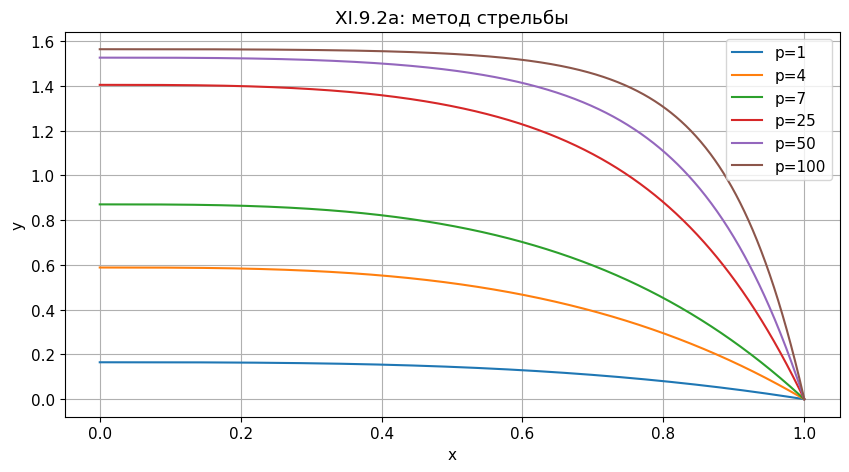

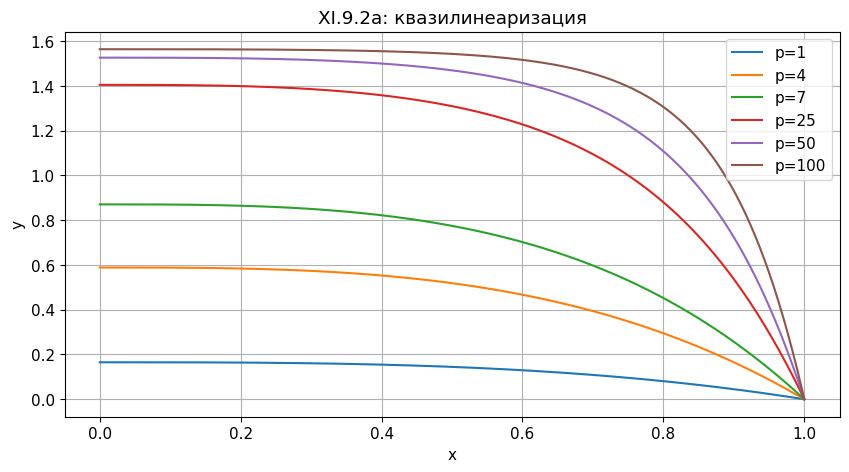

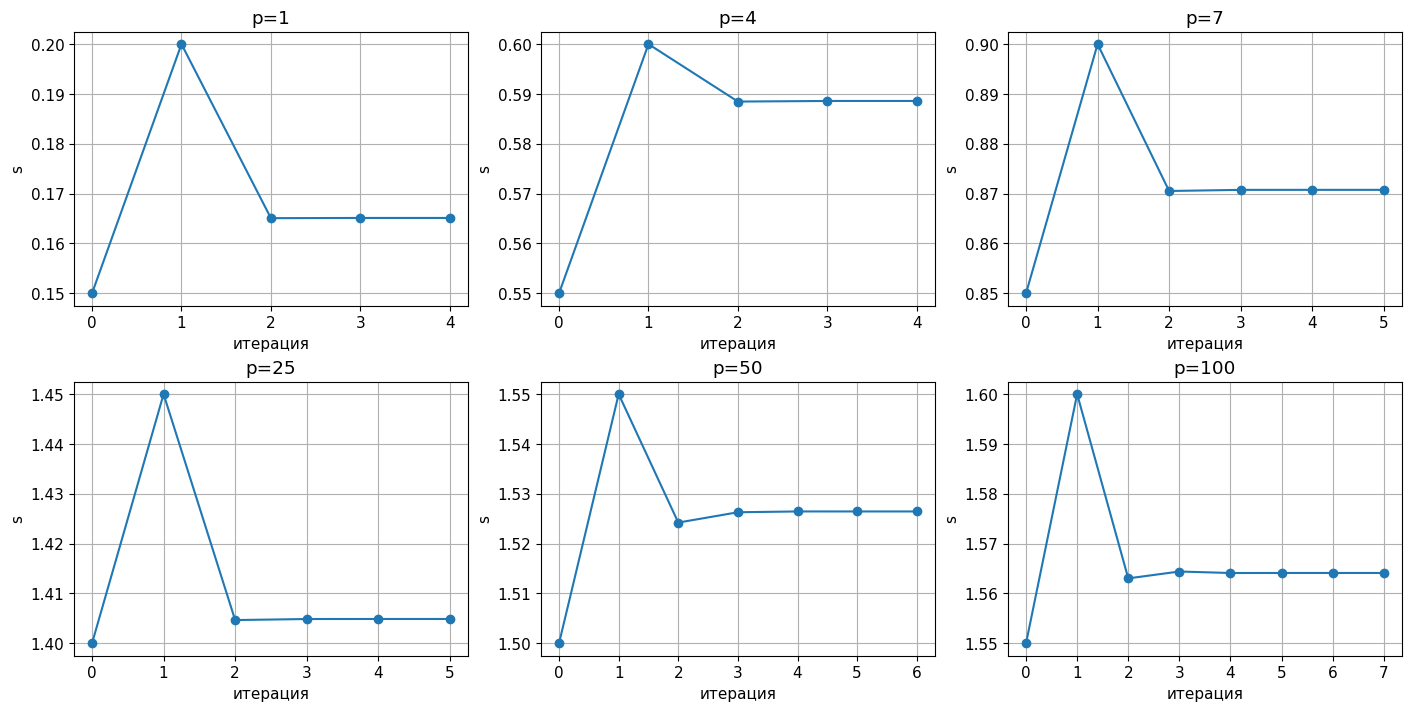

In [8]:
def rhs_922a(x, u, p):
    y, z = u
    return np.array([z, -p * x * np.cos(y)])


def shoot_922a(p, n=1000, prefer=None):
    x = np.linspace(0, 1, n + 1)

    def residual(s):
        sol = rk4_system(rhs_922a, x, [s, 0.0], args=(p,))
        return sol[-1, 0]

    left, right = scan_bracket(residual, -10.0, 10.0, prefer=prefer)
    s, hist = secant_root(residual, left, right)
    sol = rk4_system(rhs_922a, x, [s, 0.0], args=(p,))
    return x, sol[:, 0], hist


def quasi_922a(p, n=300, tol=1e-10, max_iter=30, initial=None):
    x = np.linspace(0, 1, n + 1)
    h = x[1] - x[0]
    y = np.zeros(n + 1) if initial is None else np.asarray(initial, dtype=float).copy()
    for it in range(1, max_iter + 1):
        lower = np.zeros(n)
        diag = np.zeros(n + 1)
        upper = np.zeros(n)
        rhs = np.zeros(n + 1)

        diag[0] = 1.0
        upper[0] = -1.0
        rhs[0] = -(y[0] - y[1])

        for i in range(1, n):
            F = (y[i - 1] - 2 * y[i] + y[i + 1]) / h**2 + p * x[i] * np.cos(y[i])
            lower[i - 1] = 1 / h**2
            diag[i] = -2 / h**2 - p * x[i] * np.sin(y[i])
            upper[i] = 1 / h**2
            rhs[i] = -F

        diag[n] = 1.0
        rhs[n] = -y[n]

        delta = thomas(lower, diag, upper, rhs)
        y += delta
        if np.linalg.norm(delta, ord=np.inf) < tol:
            return x, y, it
    return x, y, max_iter


p_values = [1, 4, 7, 25, 50, 100]
rows = []
shoot_curves = []
quasi_curves = []
histories_922a = {}
previous_s = None
previous_quasi = None
for p in p_values:
    xs, ys, hist = shoot_922a(p, prefer=previous_s)
    initial = None if previous_quasi is None else np.interp(np.linspace(0, 1, 301), previous_quasi[0], previous_quasi[1])
    xq, yq, iters = quasi_922a(p, initial=initial)
    previous_s = ys[0]
    previous_quasi = (xq, yq)
    histories_922a[p] = hist
    shoot_curves.append((xs, ys, f"p={p}"))
    quasi_curves.append((xq, yq, f"p={p}"))
    rows.append({
        "p": p,
        "shooting s=y(0)": ys[0],
        "shooting residual": ys[-1],
        "quasilinear iterations": iters,
        "max |shoot-quasi|": np.max(np.abs(np.interp(xq, xs, ys) - yq)),
    })

df_922a = pd.DataFrame(rows)
display(df_922a)
plot_curves(shoot_curves, "XI.9.2a: метод стрельбы")
plot_curves(quasi_curves, "XI.9.2a: квазилинеаризация")

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
for ax, p in zip(axes.flat, p_values):
    h = histories_922a[p]
    ax.plot(h["iter"], h["s"], marker="o")
    ax.set_title(f"p={p}")
    ax.set_xlabel("итерация")
    ax.set_ylabel("s")
plt.show()


## XI.9.2b

Решается задача

$$
y''+\frac{0.5}{1-0.5y}(y')^2=0,\quad y(0)=y_0,\quad y(1)=0.
$$

В методе стрельбы неизвестен начальный наклон $s=y'(0)$. В квазилинеаризации оба граничных условия имеют тип Дирихле.


,y0,shooting s=y'(0),shooting residual,quasilinear iterations,max |shoot-quasi|
0,0.25,-0.233696,5.642730e-16,3,3.995655e-09
1,0.50,-0.431585,6.007564e-16,4,2.055177e-08
2,1.00,-0.693387,1.400160e-14,4,1.982976e-07
3,1.50,-0.693628,2.359322e-12,5,1.706594e-06
4,1.80,-0.461048,7.570463e-11,5,8.903157e-06
5,1.90,-0.300022,3.839672e-13,6,2.090008e-05
6,1.95,-0.184785,1.379006e-11,6,4.080947e-05


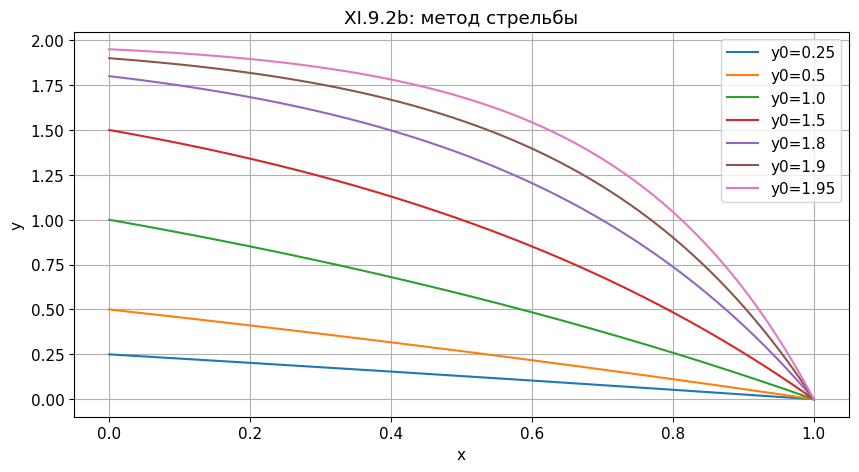

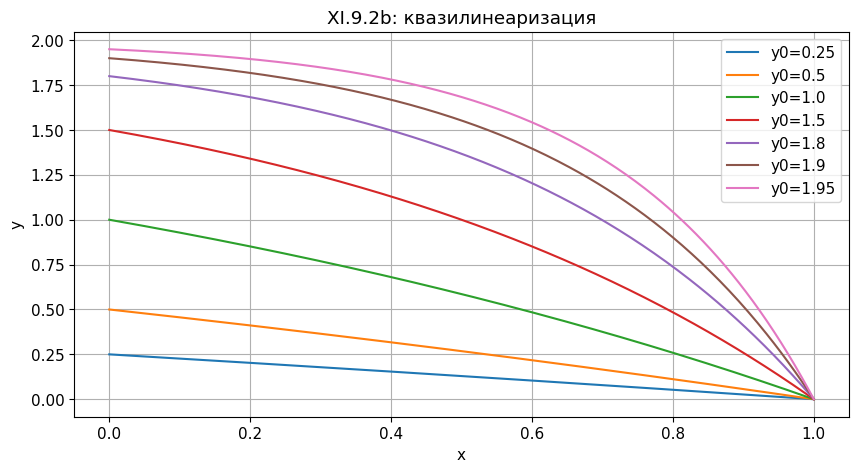

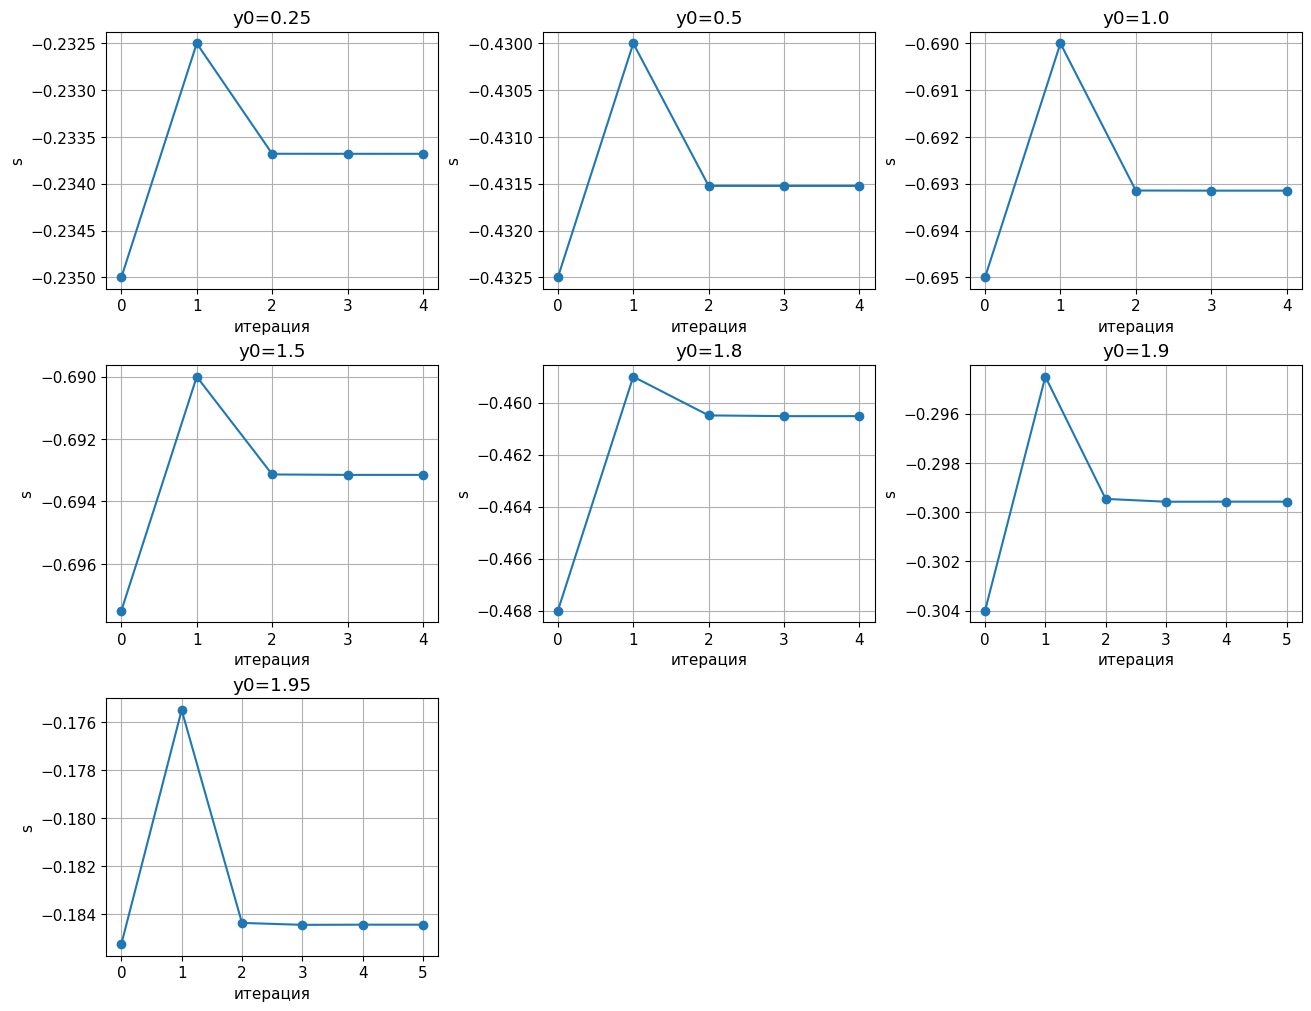

In [9]:
def rhs_922b(x, u):
    y, z = u
    return np.array([z, -0.5 * z**2 / (1 - 0.5 * y)])


def shoot_922b(y0, n=1000):
    x = np.linspace(0, 1, n + 1)

    def residual(s):
        sol = rk4_system(lambda xx, uu: rhs_922b(xx, uu), x, [y0, s])
        return sol[-1, 0]

    left, right = scan_bracket(residual, -max(2 * y0, 1.0), -1e-8, prefer=-y0)
    s, hist = secant_root(residual, left, right)
    sol = rk4_system(lambda xx, uu: rhs_922b(xx, uu), x, [y0, s])
    return x, sol[:, 0], hist


def quasi_922b(y0, n=300, tol=1e-10, max_iter=50):
    x = np.linspace(0, 1, n + 1)
    h = x[1] - x[0]
    y = y0 * (1 - x)
    for it in range(1, max_iter + 1):
        lower = np.zeros(n)
        diag = np.zeros(n + 1)
        upper = np.zeros(n)
        rhs = np.zeros(n + 1)

        diag[0] = 1.0
        rhs[0] = y0 - y[0]

        for i in range(1, n):
            yp = (y[i + 1] - y[i - 1]) / (2 * h)
            den = 1 - 0.5 * y[i]
            g = 0.5 * yp**2 / den
            gy = 0.25 * yp**2 / den**2
            gz = yp / den
            F = (y[i - 1] - 2 * y[i] + y[i + 1]) / h**2 + g
            lower[i - 1] = 1 / h**2 - gz / (2 * h)
            diag[i] = -2 / h**2 + gy
            upper[i] = 1 / h**2 + gz / (2 * h)
            rhs[i] = -F

        diag[n] = 1.0
        rhs[n] = -y[n]

        delta = thomas(lower, diag, upper, rhs)
        y += delta
        if np.linalg.norm(delta, ord=np.inf) < tol:
            return x, y, it
    return x, y, max_iter


y0_values = [0.25, 0.5, 1.0, 1.5, 1.8, 1.9, 1.95]
rows = []
shoot_curves = []
quasi_curves = []
histories_922b = {}
for y0 in y0_values:
    xs, ys, hist = shoot_922b(y0)
    xq, yq, iters = quasi_922b(y0)
    histories_922b[y0] = hist
    shoot_curves.append((xs, ys, f"y0={y0}"))
    quasi_curves.append((xq, yq, f"y0={y0}"))
    rows.append({
        "y0": y0,
        "shooting s=y'(0)": (ys[1] - ys[0]) / (xs[1] - xs[0]),
        "shooting residual": ys[-1],
        "quasilinear iterations": iters,
        "max |shoot-quasi|": np.max(np.abs(np.interp(xq, xs, ys) - yq)),
    })

df_922b = pd.DataFrame(rows)
display(df_922b)
plot_curves(shoot_curves, "XI.9.2b: метод стрельбы")
plot_curves(quasi_curves, "XI.9.2b: квазилинеаризация")

fig, axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)
for ax, y0 in zip(axes.flat, y0_values):
    h = histories_922b[y0]
    ax.plot(h["iter"], h["s"], marker="o")
    ax.set_title(f"y0={y0}")
    ax.set_xlabel("итерация")
    ax.set_ylabel("s")
for ax in axes.flat[len(y0_values):]:
    ax.axis("off")
plt.show()


## XI.9.3

Для обеих задач используется метод пристрелки. В задаче (a) невязка равна $y(1)-2$. В задаче (b) к системе добавляется переменная

$$
I'(x)=y(x),\qquad I(0)=0,
$$

и невязка равна $I(1)-1$.


,задача,s=y'(0),невязка,интеграл
0,XI.9.3a,1.842954,3.955947e-12,NaN
1,XI.9.3b,1.928912,5.773160e-15,1.0


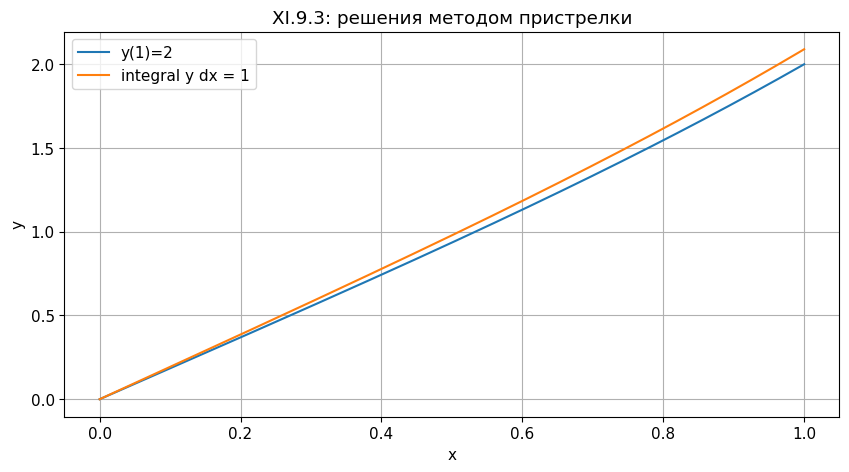

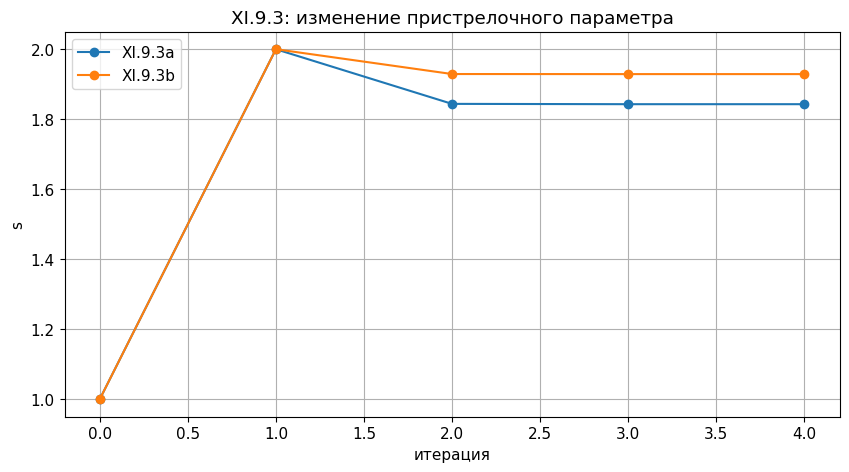

In [10]:
def rhs_923a(x, u):
    y, z = u
    return np.array([z, x * np.sqrt(max(y, 0.0))])


def rhs_923b(x, u):
    y, z, integ = u
    return np.array([z, x * np.sqrt(max(y, 0.0)), y])


def solve_923a(n=2000):
    x = np.linspace(0, 1, n + 1)

    def residual(s):
        sol = rk4_system(lambda xx, uu: rhs_923a(xx, uu), x, [0.0, s])
        return sol[-1, 0] - 2.0

    s, hist = secant_root(residual, 1.0, 2.0)
    sol = rk4_system(lambda xx, uu: rhs_923a(xx, uu), x, [0.0, s])
    return x, sol[:, 0], hist


def solve_923b(n=2000):
    x = np.linspace(0, 1, n + 1)

    def residual(s):
        sol = rk4_system(lambda xx, uu: rhs_923b(xx, uu), x, [0.0, s, 0.0])
        return sol[-1, 2] - 1.0

    s, hist = secant_root(residual, 1.0, 2.0)
    sol = rk4_system(lambda xx, uu: rhs_923b(xx, uu), x, [0.0, s, 0.0])
    return x, sol[:, 0], sol[-1, 2], hist


x_a, y_a, hist_a = solve_923a()
x_b, y_b, integral_b, hist_b = solve_923b()
display(pd.DataFrame([
    {"задача": "XI.9.3a", "s=y'(0)": hist_a.iloc[-1]["s"], "невязка": hist_a.iloc[-1]["residual"]},
    {"задача": "XI.9.3b", "s=y'(0)": hist_b.iloc[-1]["s"], "интеграл": integral_b, "невязка": hist_b.iloc[-1]["residual"]},
]))

plot_curves([
    (x_a, y_a, "y(1)=2"),
    (x_b, y_b, "integral y dx = 1"),
], "XI.9.3: решения методом пристрелки")

plt.figure()
plt.plot(hist_a["iter"], hist_a["s"], marker="o", label="XI.9.3a")
plt.plot(hist_b["iter"], hist_b["s"], marker="o", label="XI.9.3b")
plt.title("XI.9.3: изменение пристрелочного параметра")
plt.xlabel("итерация")
plt.ylabel("s")
plt.legend()
plt.show()


## XI.9.14. Частица в потенциальной яме

Уравнение

$$
y''+(\lambda-U(x))y=0,\qquad U(x)=-2\operatorname{sech}^2 x
$$

эквивалентно стационарному уравнению Шредингера

$$
-y''+U(x)y=\lambda y.
$$

Условия на бесконечности заменяются условиями Дирихле на большом отрезке $[-L,L]$. После конечно-разностной аппроксимации получается симметричная трехдиагональная матрица. Отрицательные собственные значения являются связанными уровнями энергии. Для контроля дополнительно сравниваем результат с известным точным уровнем потенциала Пёшля--Теллера: $\lambda=-1$, $y(x)\sim\operatorname{sech}x$.


,k,lambda numeric,lambda exact/reference,abs error
0,1,-1.000009,-1.0,0.000009


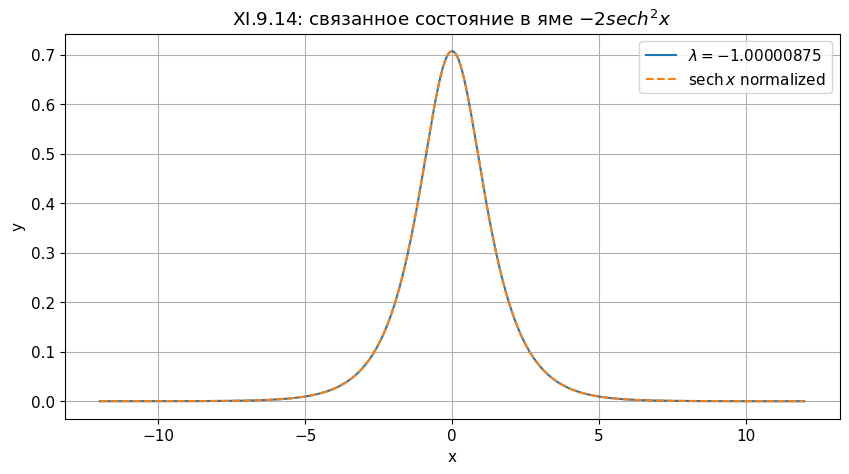

In [11]:
def sech(x):
    return 1 / np.cosh(x)


def schrodinger_well(L=12.0, n=1600):
    x = np.linspace(-L, L, n + 1)
    h = x[1] - x[0]
    xi = x[1:-1]
    U = -2 * sech(xi) ** 2
    diag = 2 / h**2 + U
    off = -np.ones(len(xi) - 1) / h**2
    vals, vecs = eigh_tridiagonal(diag, off)
    bound = vals < -1e-6
    vals_b = vals[bound]
    vecs_b = vecs[:, bound]
    full_vecs = []
    for j in range(vecs_b.shape[1]):
        y = np.zeros(n + 1)
        y[1:-1] = vecs_b[:, j]
        norm = np.sqrt(np.trapezoid(y**2, x))
        y /= norm
        if y[np.argmin(np.abs(x))] < 0:
            y *= -1
        full_vecs.append(y)
    return x, vals_b, full_vecs


xw, lambdas, eigenfunctions = schrodinger_well()
exact = sech(xw)
exact /= np.sqrt(np.trapezoid(exact**2, xw))
display(pd.DataFrame({
    "k": np.arange(1, len(lambdas) + 1),
    "lambda numeric": lambdas,
    "lambda exact/reference": [-1.0] * len(lambdas),
    "abs error": np.abs(lambdas + 1.0),
}))

plt.figure()
for lam, y in zip(lambdas, eigenfunctions):
    plt.plot(xw, y, label=fr"$\lambda={lam:.8f}$")
plt.plot(xw, exact, "--", label=r"$\operatorname{sech}x$ normalized")
plt.title("XI.9.14: связанное состояние в яме $-2 sech^2 x$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## XI.9.16. Частица в поле с потенциалом Тоды

Уравнение

$$
\ddot x=1-e^x
$$

имеет интеграл энергии:

$$
E=\frac{\dot x^2}{2}+e^x-x.
$$

При $x(0)=0$, $\dot x(0)=A$ энергия равна $E=1+\frac{A^2}{2}$. Период колебаний вычисляется квадратурой между точками поворота $x_-$ и $x_+$:

$$
T(A)=\sqrt{2}\int_{x_-}^{x_+}\frac{dx}{\sqrt{E-e^x+x}}.
$$

Условие $x(120)=0$, $\dot x(120)=A$ означает, что за время 120 проходит целое число периодов:

$$
120=mT(A),\qquad m\in\mathbb N.
$$

При ограничении $A\ge 10$ остаются только те $m$, для которых $120/m\ge T(10)$.


,T(10),число решений
0,21.248141,5


,m,A,period T(A)
0,1,59.835068,120.0
1,2,29.715404,60.0
2,3,19.611791,40.0
3,4,14.517788,30.0
4,5,11.430199,24.0


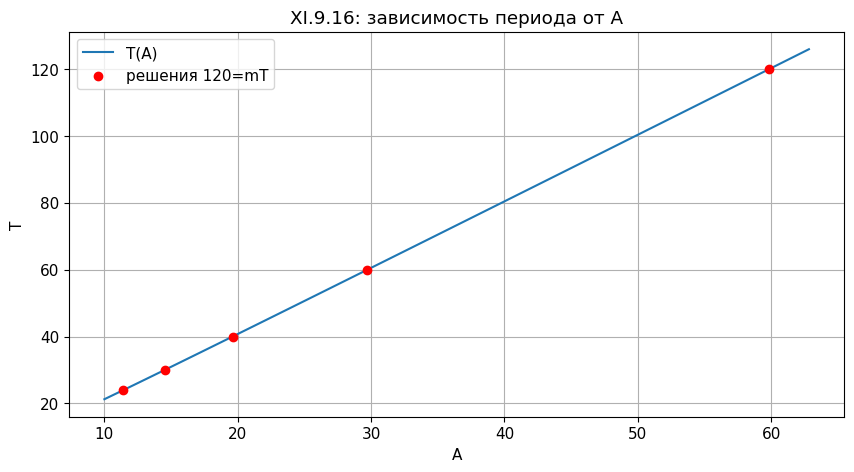

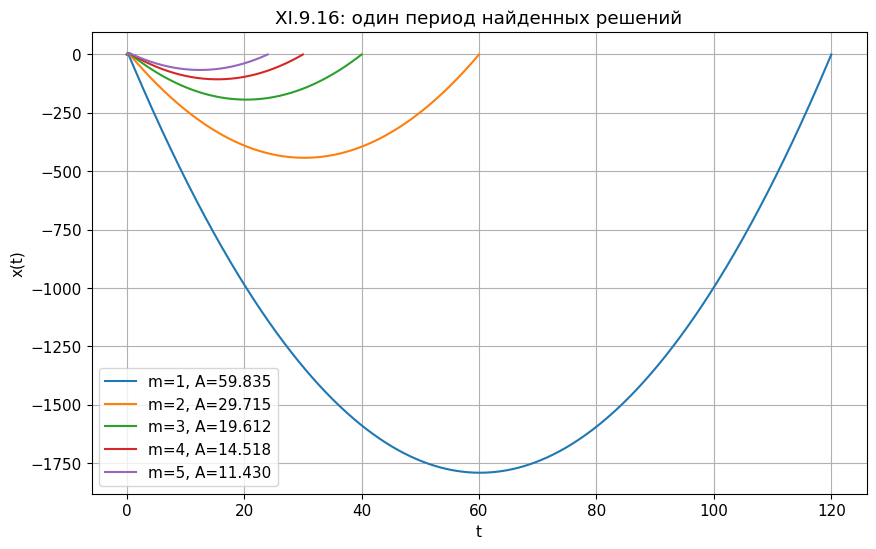

In [12]:
def toda_V(x):
    return np.exp(x) - x


def toda_turning_points(A):
    E = 1 + 0.5 * A**2
    x_left = brentq(lambda x: toda_V(x) - E, -E - 5, 0)
    x_right = brentq(lambda x: toda_V(x) - E, 0, np.log(E) + 5)
    return x_left, x_right, E


def toda_period(A):
    x_left, x_right, E = toda_turning_points(A)
    mid = 0.5 * (x_left + x_right)
    half = 0.5 * (x_right - x_left)

    def integrand(theta):
        x = mid + half * np.cos(theta)
        return half * np.sin(theta) / np.sqrt(max(E - toda_V(x), 1e-300))

    val, _ = quad(integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10, limit=200)
    return np.sqrt(2) * val


T10 = toda_period(10.0)
m_max = int(np.floor(120 / T10))
solutions = []
for m in range(1, m_max + 1):
    target = 120 / m
    hi = 10.0
    while toda_period(hi) < target:
        hi *= 1.5
    A = brentq(lambda a: toda_period(a) - target, 10.0, hi, xtol=1e-10)
    solutions.append({"m": m, "A": A, "period T(A)": target})

df_toda = pd.DataFrame(solutions)
display(pd.DataFrame([{"T(10)": T10, "число решений": len(df_toda)}]))
display(df_toda)

A_grid = np.linspace(10, max(df_toda["A"]) * 1.05, 120)
T_grid = np.array([toda_period(A) for A in A_grid])
plt.figure()
plt.plot(A_grid, T_grid, label="T(A)")
plt.scatter(df_toda["A"], df_toda["period T(A)"], color="red", zorder=3, label="решения 120=mT")
plt.title("XI.9.16: зависимость периода от A")
plt.xlabel("A")
plt.ylabel("T")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for row in solutions:
    A = row["A"]
    sol = solve_ivp(
        lambda t, u: [u[1], 1 - np.exp(u[0])],
        (0, row["period T(A)"]),
        [0, A],
        max_step=row["period T(A)"] / 1000,
        rtol=1e-9,
        atol=1e-11,
    )
    plt.plot(sol.t, sol.y[0], label=f"m={int(row['m'])}, A={A:.3f}")
plt.title("XI.9.16: один период найденных решений")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.show()


## Выводы

1. Метод стрельбы хорошо работает для рассмотренных одномерных краевых задач: число неизвестных пристрелочных параметров равно одному, а невязка является гладкой функцией параметра. Графики истории секущей показывают быструю стабилизацию параметра.
2. Квазилинеаризация дает близкие к стрельбе решения. На каждой итерации возникает трехдиагональная система, поэтому метод прогонки делает стоимость итерации линейной по числу узлов сетки.
3. Для ямы $U(x)=-2\operatorname{sech}^2x$ найден один отрицательный уровень энергии. Численное значение совпадает с аналитическим $\lambda=-1$ с ошибкой сеточной аппроксимации.
4. Для потенциала Тоды период монотонно растет с $A$. Так как $T(10)\approx 21.248$, условие $120=mT(A)$ выполняется только для $m=1,\ldots,5$. Поэтому при $A\ge 10$ получается пять периодических решений.
